In [4]:
library(haven)
library(tidyverse)

# Load the data
setwd("climate-attitude-capstone-project/data")
ccam <- read_sav("CCAM-survey-data/CCAM SPSS Data 2008-2024.sav") %>%
  mutate(across(where(is.labelled), as_factor))

cat("Loaded", nrow(ccam), "observations\n\n")

head(ccam)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


ERROR: Error in setwd("climate-attitude-capstone-project/data"): cannot change working directory


In [11]:
summary(ccam)

    case_ID            wave            year        weight_wave    
 Min.   :    2   Nov 2008: 2164   2019   : 2594   Min.   :0.0600  
 1st Qu.:16589   Oct 2015: 1330   2015   : 2593   1st Qu.:0.6388  
 Median :32250   Oct 2017: 1304   2017   : 2570   Median :0.8528  
 Mean   :31638   Nov 2019: 1303   2016   : 2430   Mean   :1.0000  
 3rd Qu.:46450   Apr 2019: 1291   2018   : 2392   3rd Qu.:1.2090  
 Max.   :63052   Mar 2018: 1278   2014   : 2288   Max.   :5.2800  
                 (Other) :26639   (Other):20442                   
 weight_aggregate      happening    
 Min.   :0.0000   Refused   :   77  
 1st Qu.:0.5820   No        : 5476  
 Median :0.8379   Don't know: 5609  
 Mean   :0.9447   Yes       :24147  
 3rd Qu.:1.1944                     
 Max.   :5.4276                     
                                    
                                                  cause_original 
 Refused                                                 :  109  
 Caused mostly by human activities  

In [12]:
head(ccam)

case_ID,wave,year,weight_wave,weight_aggregate,happening,cause_original,cause_other_text,cause_recoded,sci_consensus,⋯,employment,house_head,house_size,house_ages0to1,house_ages2to5,house_ages6to12,house_ages13to17,house_ages18plus,house_type,house_own
<dbl>,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<chr>,<fct>,<fct>,⋯,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
2,Nov 2008,2008,0.54,0.2842237,Yes,Caused mostly by human activities,,Caused mostly by human activities,Most scientists think global warming is happening,⋯,Not working,Not head of household,3,0,0,0,0,3,One-family house detached from any other house,Owned or being bought by you or someone in your household
3,Nov 2008,2008,0.85,0.4473891,Don't know,Caused mostly by human activities,,Caused mostly by human activities,Don't know enough to say,⋯,Not working,Head of household,2,0,0,0,0,2,"Other (mobile home, boat, RV, van, etc.)",Rented for cash
5,Nov 2008,2008,0.49,0.2579067,Don't know,Caused mostly by natural changes in the environment,,Caused mostly by natural changes in the environment,There is a lot of disagreement among scientists about whether or not global warming is happening,⋯,Not working,Head of household,2,0,0,0,0,2,One-family house detached from any other house,Owned or being bought by you or someone in your household
6,Nov 2008,2008,0.29,0.1526386,Yes,Caused mostly by natural changes in the environment,,Caused mostly by natural changes in the environment,Most scientists think global warming is happening,⋯,Not working,Head of household,2,0,0,0,0,2,One-family house detached from any other house,Owned or being bought by you or someone in your household
7,Nov 2008,2008,1.29,0.6789787,Yes,Caused mostly by human activities,,Caused mostly by human activities,There is a lot of disagreement among scientists about whether or not global warming is happening,⋯,Working,Head of household,2,0,0,0,0,2,One-family house detached from any other house,Owned or being bought by you or someone in your household
8,Nov 2008,2008,2.56,1.3474307,Don't know,Caused mostly by natural changes in the environment,,Caused mostly by natural changes in the environment,There is a lot of disagreement among scientists about whether or not global warming is happening,⋯,Working,Head of household,3,0,0,1,0,2,One-family house attached to one or more houses (such as a condo or townhouse),Owned or being bought by you or someone in your household


In [7]:
# -----------------------------------------------------------------------------
# 1. SIMPLE WEIGHTED FREQUENCIES
# -----------------------------------------------------------------------------
#
# The CCAM data includes survey weights to make the sample representative.
# Use weight_wave for within-wave analyses, weight_aggregate for pooled data.
#
# Key principle: multiply counts by weights, then calculate proportions
# -----------------------------------------------------------------------------

library(tidyverse)
library(dplyr)

cat("=== 1. WEIGHTED FREQUENCIES ===\n\n")

# Unweighted frequency of worry
cat("-- Unweighted frequency of worry --\n")
ccam %>%
  count(worry) %>%
  mutate(pct = n / sum(n) * 100) %>%
  print()

# Weighted frequency of worry (using aggregate weight for pooled data)
cat("\n-- Weighted frequency of worry --\n")
ccam %>%
  group_by(worry) %>%
  summarise(
    n_unweighted = n(),
    n_weighted = sum(weight_aggregate, na.rm = TRUE)
  ) %>%
  mutate(
    pct_unweighted = n_unweighted / sum(n_unweighted) * 100,
    pct_weighted = n_weighted / sum(n_weighted) * 100
  ) %>%
  print()


=== 1. WEIGHTED FREQUENCIES ===



-- Unweighted frequency of worry --


# A tibble: 5 × 3
  worry                  n    pct
  <fct>              <int>  <dbl>
1 Refused               84  0.238
2 Not at all worried  5867 16.6  
3 Not very worried    8703 24.6  
4 Somewhat worried   13647 38.7  
5 Very worried        7008 19.8  



-- Weighted frequency of worry --


# A tibble: 5 × 5
  worry              n_unweighted n_weighted pct_unweighted pct_weighted
  <fct>                     <int>      <dbl>          <dbl>        <dbl>
1 Refused                      84       70.6          0.238        0.212
2 Not at all worried         5867     5337.          16.6         16.0  
3 Not very worried           8703     7848.          24.6         23.5  
4 Somewhat worried          13647    13206.          38.7         39.6  
5 Very worried               7008     6894.          19.8         20.7  


In [8]:
# -----------------------------------------------------------------------------
# 2. WEIGHTED FREQUENCIES BY YEAR
# -----------------------------------------------------------------------------
#
# When analyzing by year, use weight_wave (weights calibrated per wave)
# This ensures each year's sample is representative of that year's population
# -----------------------------------------------------------------------------

cat("\n=== 2. WEIGHTED FREQUENCIES BY YEAR ===\n\n")

# Calculate weighted proportion "worried" by year
worry_by_year <- ccam %>%
  # Create binary worried variable
  mutate(worried = worry %in% c("Somewhat worried", "Very worried")) %>%
  group_by(year) %>%
  summarise(
    n = n(),
    n_weighted = sum(weight_wave, na.rm = TRUE),
    # Weighted proportion worried
    pct_worried_unweighted = mean(worried, na.rm = TRUE) * 100,
    pct_worried_weighted = sum(worried * weight_wave, na.rm = TRUE) /
                           sum(weight_wave, na.rm = TRUE) * 100
  )

cat("-- Proportion worried by year (weighted vs unweighted) --\n")
print(worry_by_year, n = 20)

# -------------------------------------------------------------------


=== 2. WEIGHTED FREQUENCIES BY YEAR ===



-- Proportion worried by year (weighted vs unweighted) --


# A tibble: 16 × 5
   year      n n_weighted pct_worried_unweighted pct_worried_weighted
   <fct> <int>      <dbl>                  <dbl>                <dbl>
 1 2008   2164      2164.                   59.9                 62.1
 2 2010   2025      2025.                   50.4                 50.7
 3 2011   2010      2010.                   50.9                 52.2
 4 2012   2069      2069.                   53.2                 55.6
 5 2013   1875      1875.                   51.2                 51.9
 6 2014   2288      2288.                   53.9                 55.8
 7 2015   2593      2593.                   54.1                 54.8
 8 2016   2430      2430.                   57.7                 59.2
 9 2017   2570      2570.                   58.4                 60.0
10 2018   2392      2392.                   64.4                 65.1
11 2019   2594      2594.                   62.0                 64.2
12 2020   2065      2065.                   64.3                 66.0
1

In [10]:
#3. WEIGHTED CROSSTABS
# -----------------------------------------------------------------------------
#
# Crosstabs show the relationship between two categorical variables
# With weights, we calculate weighted counts and row/column percentages
# -----------------------------------------------------------------------------

cat("\n=== 3. WEIGHTED CROSSTABS ===\n\n")

# Crosstab: Worry by Region (using 4-region variable)
cat("-- Crosstab: Worry by Region (weighted column %) --\n")

crosstab_region_worry <- ccam %>%
  filter(!is.na(region4), !is.na(worry)) %>%
  group_by(region4, worry) %>%
  summarise(
    n_weighted = sum(weight_aggregate, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # Calculate column percentages (within each region)
  group_by(region4) %>%
  mutate(
    pct = n_weighted / sum(n_weighted) * 100
  ) %>%
  ungroup()

# Display as a wide table
crosstab_wide <- crosstab_region_worry %>%
  select(region4, worry, pct) %>%
  pivot_wider(names_from = region4, values_from = pct)

print(crosstab_wide)

# Crosstab: Worry by Ideology
cat("\n-- Crosstab: Worry by Ideology (weighted column %) --\n")

crosstab_ideo_worry <- ccam %>%
  filter(!is.na(ideology), !is.na(worry)) %>%
  group_by(ideology, worry) %>%
  summarise(
    n_weighted = sum(weight_aggregate, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(ideology) %>%
  mutate(pct = n_weighted / sum(n_weighted) * 100) %>%
  ungroup()

crosstab_ideo_wide <- crosstab_ideo_worry %>%
  select(ideology, worry, pct) %>%
  pivot_wider(names_from = ideology, values_from = pct)

print(crosstab_ideo_wide)



=== 3. WEIGHTED CROSSTABS ===



-- Crosstab: Worry by Region (weighted column %) --


# A tibble: 5 × 5
  worry              Northeast Midwest  South   West
  <fct>                  <dbl>   <dbl>  <dbl>  <dbl>
1 Refused                0.180   0.211  0.182  0.285
2 Not at all worried    13.1    16.9   17.7   14.6  
3 Not very worried      22.1    26.7   24.4   20.4  
4 Somewhat worried      43.3    38.6   38.7   39.1  
5 Very worried          21.3    17.6   18.9   25.7  



-- Crosstab: Worry by Ideology (weighted column %) --


# A tibble: 5 × 7
  worry         Refused `Very liberal` `Somewhat liberal` Moderate, middle of …¹
  <fct>           <dbl>          <dbl>              <dbl>                  <dbl>
1 Refused          7.43           0               0.00771                 0.0734
2 Not at all w…   18.1            3.98            3.88                   10.3   
3 Not very wor…   23.0            8.15           12.3                    23.8   
4 Somewhat wor…   38.7           33.0            49.1                    47.2   
5 Very worried    12.8           54.9            34.7                    18.6   
# ℹ abbreviated name: ¹​`Moderate, middle of the road`
# ℹ 2 more variables: `Somewhat conservative` <dbl>, `Very conservative` <dbl>


In [14]:
library(ggplot2)

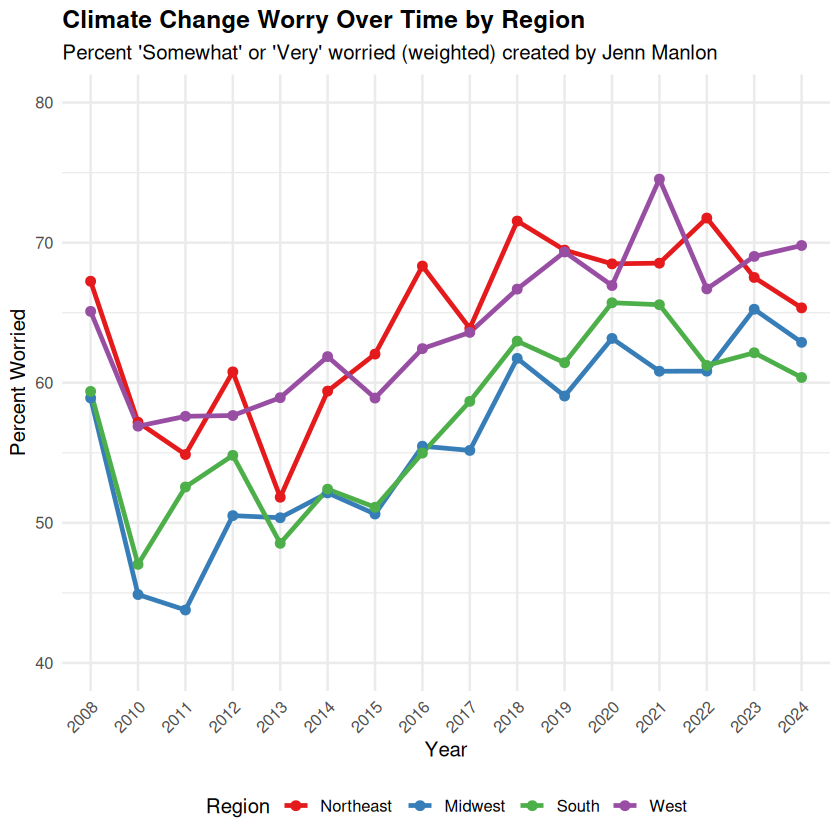

In [8]:
# 5. BAR CHART: PERCENT WORRIED BY REGION OVER TIME
# -----------------------------------------------------------------------------
#
# Shows trend in worry by region across years
# -----------------------------------------------------------------------------

# Calculate weighted % worried by region and year
worry_region_year <- ccam %>%
  filter(!is.na(region4)) %>%
  mutate(worried = worry %in% c("Somewhat worried", "Very worried")) %>%
  group_by(year, region4) %>%
  summarise(
    pct_worried = sum(worried * weight_wave, na.rm = TRUE) /
                  sum(weight_wave, na.rm = TRUE) * 100,
    .groups = "drop"
  )

# Line chart: Worry trends by region
p2 <- ggplot(worry_region_year, aes(x = year, y = pct_worried,
                                     color = region4, group = region4)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_color_brewer(palette = "Set1", name = "Region") +
  scale_y_continuous(limits = c(40, 80)) +
  labs(
    title = "Climate Change Worry Over Time by Region",
    subtitle = "Percent 'Somewhat' or 'Very' worried (weighted) created by Jenn Manlon",
    x = "Year",
    y = "Percent Worried"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )
print(p2)

Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”


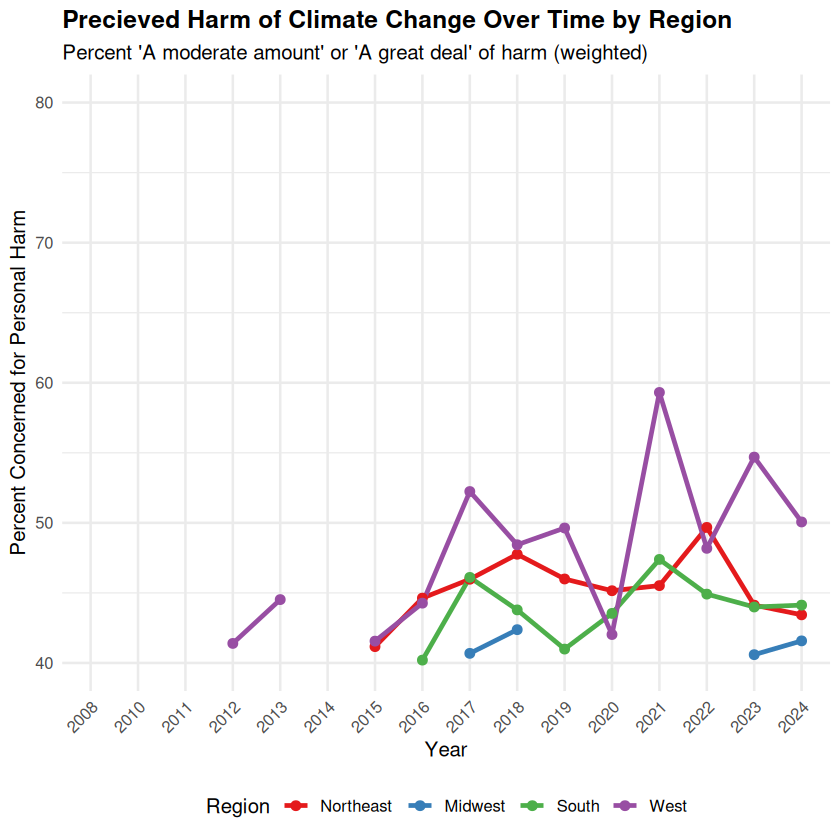

In [5]:
# 5. BAR CHART: PERCENT HARM PERSONALLY BY REGION OVER TIME
# -----------------------------------------------------------------------------
#
# Shows trend in harm personally by region across years
# -----------------------------------------------------------------------------


# Calculate weighted % harm by region and year
harm_region_year <- ccam %>%
  filter(!is.na(region4)) %>%
  mutate(harm = harm_personally %in% c("A moderate amount", "A great deal")) %>%
  group_by(year, region4) %>%
  summarise(
    pct_harm = sum(harm * weight_wave, na.rm = TRUE) /
                  sum(weight_wave, na.rm = TRUE) * 100,
    .groups = "drop"
  )

# Line chart: harm trends by region
p2 <- ggplot(harm_region_year, aes(x = year, y = pct_harm,
                                     color = region4, group = region4)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_color_brewer(palette = "Set1", name = "Region") +
  scale_y_continuous(limits = c(40, 80)) +
  labs(
    title = "Precieved Harm of Climate Change Over Time by Region",
    subtitle = "Percent 'A moderate amount' or 'A great deal' of harm (weighted)",
    x = "Year",
    y = "Percent Concerned for Personal Harm"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )
print(p2)

In [3]:
# 6. EFFECT SIZE PLOT: REGIONAL DIFFERENCES
# -----------------------------------------------------------------------------
#
# Effect sizes quantify the magnitude of differences between groups
# Here we calculate the difference in % worried relative to the national average
# This shows which regions are more/less worried than average
# -----------------------------------------------------------------------------

cat("\n=== 5. EFFECT SIZE CALCULATIONS ===\n\n")

# Calculate overall weighted % worried
overall_worried <- ccam %>%
  mutate(worried = worry %in% c("Somewhat worried", "Very worried")) %>%
  summarise(
    pct = sum(worried * weight_aggregate, na.rm = TRUE) /
          sum(weight_aggregate, na.rm = TRUE) * 100
  ) %>%
  pull(pct)

cat("Overall % worried (weighted):", round(overall_worried, 1), "%\n\n")

# Calculate regional effects (difference from national average)
regional_effects <- ccam %>%
  filter(!is.na(region4)) %>%
  mutate(worried = worry %in% c("Somewhat worried", "Very worried")) %>%
  group_by(region4) %>%
  summarise(
    n = n(),
    n_weighted = sum(weight_aggregate, na.rm = TRUE),
    pct_worried = sum(worried * weight_aggregate, na.rm = TRUE) /
                  sum(weight_aggregate, na.rm = TRUE) * 100,
    # Standard error for weighted proportion (approximate)
    se = sqrt(pct_worried * (100 - pct_worried) / n),
    .groups = "drop"
  ) %>%
  mutate(
    # Effect = difference from national average
    effect = pct_worried - overall_worried,
    # 95% confidence interval
    ci_lower = effect - 1.96 * se,
    ci_upper = effect + 1.96 * se
  )

cat("-- Regional effects (difference from national average) --\n")
print(regional_effects)

# Effect size plot
p3 <- ggplot(regional_effects, aes(x = reorder(region4, effect), y = effect)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper),
                width = 0.2, color = "gray40") +
  geom_point(aes(color = effect > 0), size = 4) +
  scale_color_manual(values = c("TRUE" = "#d73027", "FALSE" = "#4575b4"),
                     guide = "none") +
  coord_flip() +
  labs(
    title = "Regional Differences in Climate Change Worry",
    subtitle = paste0("Percentage points above/below national average (",
                      round(overall_worried, 1), "%)"),
    x = NULL,
    y = "Difference from National Average (percentage points)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.major.y = element_blank()
  )

ggsave("output/tutorial_regional_effect_sizes.png", p3, width = 9, height = 5, dpi = 300)
cat("\nSaved: output/tutorial_regional_effect_sizes.png\n")

# -----------------------------------------------------------------------------
# 7. EFFECT SIZE PLOT: IDEOLOGY WITHIN EACH REGION
# -----------------------------------------------------------------------------
#
# More complex effect sizes: how does ideology affect worry within each region?
# This shows the "ideology gap" in worry by region
# -----------------------------------------------------------------------------

cat("\n=== 6. IDEOLOGY EFFECTS BY REGION ===\n\n")

# Calculate % worried by ideology within each region
ideology_region <- ccam %>%
  filter(!is.na(region4), !is.na(ideology)) %>%
  mutate(
    worried = worry %in% c("Somewhat worried", "Very worried"),
    # Collapse ideology to 3 categories
    ideology3 = case_when(
      ideology %in% c("Very liberal", "Somewhat liberal") ~ "Liberal",
      ideology == "Moderate, middle of the road" ~ "Moderate",
      ideology %in% c("Somewhat conservative", "Very conservative") ~ "Conservative",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(ideology3)) %>%
  group_by(region4, ideology3) %>%
  summarise(
    n = n(),
    pct_worried = sum(worried * weight_aggregate, na.rm = TRUE) /
                  sum(weight_aggregate, na.rm = TRUE) * 100,
    se = sqrt(pct_worried * (100 - pct_worried) / n),
    .groups = "drop"
  ) %>%
  mutate(
    ci_lower = pct_worried - 1.96 * se,
    ci_upper = pct_worried + 1.96 * se,
    ideology3 = factor(ideology3, levels = c("Liberal", "Moderate", "Conservative"))
  )

cat("-- Percent worried by ideology and region --\n")
ideology_region %>%
  select(region4, ideology3, pct_worried) %>%
  pivot_wider(names_from = ideology3, values_from = pct_worried) %>%
  mutate(
    `Liberal-Conservative Gap` = Liberal - Conservative
  ) %>%
  print()

# Effect size plot: Ideology effects by region
p4 <- ggplot(ideology_region, aes(x = ideology3, y = pct_worried,
                                   fill = ideology3)) +
  geom_col(alpha = 0.85) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), width = 0.2) +
  facet_wrap(~region4, nrow = 1) +
  scale_fill_manual(
    values = c("Liberal" = "#2166ac", "Moderate" = "#f7f7f7",
               "Conservative" = "#b2182b"),
    guide = "none"
  ) +
  scale_y_continuous(limits = c(0, 100)) +
  labs(
    title = "Climate Worry by Ideology Across U.S. Regions",
    subtitle = "Percent 'Somewhat' or 'Very' worried (weighted), with 95% CI",
    x = NULL,
    y = "Percent Worried"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank()
  )

ggsave("output/tutorial_ideology_by_region.png", p4, width = 12, height = 6, dpi = 300)
cat("\nSaved: output/tutorial_ideology_by_region.png\n")

# -----------------------------------------------------------------------------
# 8. SUMMARY HELPER FUNCTION
# -----------------------------------------------------------------------------
#
# Here's a reusable function for weighted crosstabs
# -----------------------------------------------------------------------------

cat("\n=== 7. REUSABLE FUNCTION ===\n\n")

#' Calculate weighted crosstab with percentages
#'
#' @param data Data frame
#' @param row_var Row variable (unquoted)
#' @param col_var Column variable (unquoted)
#' @param weight_var Weight variable (unquoted)
#' @param pct_type "row", "column", or "total"
#' @return Tibble with weighted counts and percentages
weighted_crosstab <- function(data, row_var, col_var, weight_var, pct_type = "column") {
  result <- data %>%
    filter(!is.na({{row_var}}), !is.na({{col_var}})) %>%
    group_by({{row_var}}, {{col_var}}) %>%
    summarise(
      n_unweighted = n(),
      n_weighted = sum({{weight_var}}, na.rm = TRUE),
      .groups = "drop"
    )

  if (pct_type == "column") {
    result <- result %>%
      group_by({{col_var}}) %>%
      mutate(pct = n_weighted / sum(n_weighted) * 100)
  } else if (pct_type == "row") {
    result <- result %>%
      group_by({{row_var}}) %>%
      mutate(pct = n_weighted / sum(n_weighted) * 100)
  } else {
    result <- result %>%
      mutate(pct = n_weighted / sum(n_weighted) * 100)
  }

  return(ungroup(result))
}

# Example usage
cat("Example: weighted_crosstab(ccam, worry, region4, weight_aggregate)\n\n")
weighted_crosstab(ccam, worry, region4, weight_aggregate) %>%
  select(worry, region4, pct) %>%
  pivot_wider(names_from = region4, values_from = pct) %>%
  print()

# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------

cat("\n")
cat("=" %>% rep(60) %>% paste(collapse = ""), "\n")
cat("TUTORIAL COMPLETE\n")
cat("=" %>% rep(60) %>% paste(collapse = ""), "\n\n")

cat("Files created:\n")
cat("  - output/tutorial_worry_by_region.png\n")
cat("  - output/tutorial_worry_trend_by_region.png\n")
cat("  - output/tutorial_regional_effect_sizes.png\n")
cat("  - output/tutorial_ideology_by_region.png\n")

cat("\nKey concepts covered:\n")
cat("  1. Weighted frequencies with survey weights\n")
cat("  2. Weighted crosstabs (row/column percentages)\n")
cat("  3. Grouped bar charts for categorical comparisons\n")
cat("  4. Line charts for trends over time\n")
cat("  5. Effect size plots with confidence intervals\n")
cat("  6. Reusable function for weighted crosstabs\n")



=== 5. EFFECT SIZE CALCULATIONS ===



ERROR: Error in ccam %>% mutate(worried = worry %in% c("Somewhat worried", "Very worried")) %>% : could not find function "%>%"
